In [2]:
import numpy as np
X,y = np.load("gamma_covert_no_pca.npz")["X"], np.load("gamma_covert_no_pca.npz")["y"]


#### 0: up
#### 1: down
#### 2: left
#### 3: right

In [3]:
y_up = ((y==0).astype(int)).copy()

In [4]:
def gfp(data):
    return data.std(axis=1, ddof=0)

In [74]:
X_gfp.shape

(526, 154)

In [5]:
X_gfp = gfp(X)

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_gfp, y_up, test_size=0.2, random_state=68)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.79      1.00      0.88        84
           1       0.00      0.00      0.00        22

    accuracy                           0.79       106
   macro avg       0.40      0.50      0.44       106
weighted avg       0.63      0.79      0.70       106



In [49]:
from catboost import CatBoostClassifier 
model = CatBoostClassifier(iterations=1000, learning_rate=0.1, depth=6, verbose=0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.79      0.98      0.87        84
           1       0.00      0.00      0.00        22

    accuracy                           0.77       106
   macro avg       0.39      0.49      0.44       106
weighted avg       0.62      0.77      0.69       106



In [7]:
import torch
from torch.nn import Linear, ReLU, Conv1d, MaxPool1d, Dropout, LSTM, Upsample
from torch.utils.data import DataLoader, TensorDataset

class AutoEncoder(torch.nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(AutoEncoder, self).__init__()
        self.encoder = torch.nn.Sequential(
            Conv1d(input_size, hidden_size, kernel_size=3, padding=1),
            ReLU(),
            MaxPool1d(kernel_size=2)
        )
        self.lstm = LSTM(hidden_size, hidden_size, num_layers, batch_first=True)
        self.decoder = torch.nn.Sequential(
            Upsample(scale_factor=2),
            Conv1d(hidden_size, input_size, kernel_size=3, padding=1),
        )

    def forward(self, x):
        encoded = self.encoder(x)          # (N, hidden_size, seq_len//2)
        encoded = encoded.permute(0, 2, 1) # (N, seq_len//2, hidden_size) for LSTM
        lstm_out, _ = self.lstm(encoded)   # (N, seq_len//2, hidden_size)
        lstm_out = lstm_out.permute(0, 2, 1) # (N, hidden_size, seq_len//2) for Conv1d
        decoded = self.decoder(lstm_out)   # (N, input_size, seq_len)
        return decoded

In [8]:
X_up = X[y_up==0]
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_up_reshaped = X_up.reshape(X_up.shape[0], X_up.shape[1] * X_up.shape[2])
X_up_scaled = scaler.fit_transform(X_up_reshaped)
X_up_scaled = X_up_scaled.reshape(X_up.shape)

In [106]:
device = torch.device("mps")

def train_autoencoder(X, X_test, input_size, hidden_size, num_layers, batch_size, num_epochs):
    model = AutoEncoder(input_size, hidden_size, num_layers).to(device)
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

    train_dataset = TensorDataset(torch.tensor(X, dtype=torch.float32))
    test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for data in train_loader:
            inputs = data[0].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, inputs)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        test_loss = 0
        with torch.no_grad():
            for data in test_loader:
                inputs = data[0].to(device)
                outputs = model(inputs)
                loss = criterion(outputs, inputs)
                test_loss += loss.item()
            test_loss /= len(test_loader)

        print(f"Epoch {epoch+1}/{num_epochs} - Train loss: {train_loss:.4f}, Test loss: {test_loss:.4f}")

    return model


In [23]:
# X_train, X_test, y_train, y_test = train_test_split(X_gfp, y_up, test_size=0.2, random_state=68)
# X_up_scaled_train, X_up_scaled_test = train_test_split(X_up_scaled, test_size=0.2, random_state=2)

# model = train_autoencoder(X_up_scaled_train, X_up_scaled_test,input_size=X_up.shape[1], hidden_size=64, num_layers=2, batch_size=32, num_epochs=100)

In [10]:
# loss = torch.nn.MSELoss()
X_reshaped = X.reshape(X.shape[0], X.shape[1] * X.shape[2])
X_scaled = scaler.transform(X_reshaped)
X_scaled = X_scaled.reshape(X.shape)

In [142]:
model.eval()
for i in range(len(X)):
    with torch.no_grad():
        out = model(torch.tensor(X_scaled[i].reshape(1, X[i].shape[0], X[i].shape[1]), dtype=torch.float32).to(device)).detach().cpu()
        print(f"Item {i}: {loss(out,torch.tensor(X_scaled[i].reshape(1, X[i].shape[0], X[i].shape[1]), dtype=torch.float32)): .4f}, label: {y[i]}")

Item 0:  0.1742, label: 0
Item 1:  0.0826, label: 0
Item 2:  0.0926, label: 0
Item 3:  0.0704, label: 0
Item 4:  0.0627, label: 0
Item 5:  0.1038, label: 1
Item 6:  0.0675, label: 1
Item 7:  0.0700, label: 1
Item 8:  0.0871, label: 1
Item 9:  0.0653, label: 1
Item 10:  0.0889, label: 2
Item 11:  0.0644, label: 2
Item 12:  0.0726, label: 2
Item 13:  0.0940, label: 2
Item 14:  0.0712, label: 2
Item 15:  0.1866, label: 3
Item 16:  0.1131, label: 3
Item 17:  0.0882, label: 3
Item 18:  0.0762, label: 3
Item 19:  0.0903, label: 3
Item 20:  0.0783, label: 3
Item 21:  0.0843, label: 3
Item 22:  0.0606, label: 3
Item 23:  0.0698, label: 3
Item 24:  0.0662, label: 3
Item 25:  0.0246, label: 0
Item 26:  0.0257, label: 0
Item 27:  0.0324, label: 0
Item 28:  0.0445, label: 0
Item 29:  0.0442, label: 0
Item 30:  0.0209, label: 1
Item 31:  0.0335, label: 1
Item 32:  0.0223, label: 1
Item 33:  0.0403, label: 1
Item 34:  0.0458, label: 1
Item 35:  0.0266, label: 2
Item 36:  0.0286, label: 2
Item 37:  0

In [47]:
from torch import nn
import torch.nn.functional as F

class CNN_LSTM_Classifier(nn.Module):
    def __init__(self, n_channels, n_timepoints, n_classes=4):
        super(CNN_LSTM_Classifier, self).__init__()

        self.conv1 = nn.Conv1d(in_channels=n_channels, out_channels=14, groups=n_channels, kernel_size=16, padding='valid')
        # self.conv2 = nn.Conv1d(in_channels=28, out_channels=56, groups=28, kernel_size=32, padding='valid')
        # self.conv3 = nn.Conv1d(in_channels=56, out_channels=128, groups=1, kernel_size=32, padding='valid')

        self.pool = nn.AvgPool1d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout(0.3)
        
        # self.lstm = nn.LSTM(128, 64, num_layers=2, batch_first=True, dropout=0.3)
        # self.dropout2 = nn.Dropout(0.5)
        
        self.classifier = nn.Linear(966, n_classes)
        
    def forward(self, x):
        x = F.relu(self.conv1(x))
        
        # x = F.relu(self.conv2(x))
        x = self.pool(x)
        
        # x = F.relu(self.conv3(x))
        # x = self.pool(x)
        
        x = self.dropout1(x)
        
        # x = x.transpose(1, 2)
        
        # lstm_out, (h_n, c_n) = self.lstm(x)
        
        # x = lstm_out[:, -1, :]
        # flatten to go to linear layer
        x = x.view(x.size(0), -1)
        # x = self.dropout2(x)
        x = self.classifier(x)
        
        return x

X_up = X.copy()
y_up = ((y==0).astype(int)).copy()
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_up_reshaped = X_up.reshape(X_up.shape[0], X_up.shape[1] * X_up.shape[2])
X_up_scaled = scaler.fit_transform(X_up_reshaped)
X_up_scaled = X_up_scaled.reshape(X_up.shape)
X_up_scaled_train, X_up_scaled_test, y_up_train, y_up_test = train_test_split(X_up_scaled, y_up, test_size=0.2, random_state=2)

X_train_tensor = torch.tensor(X_up_scaled_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_up_scaled_test, dtype=torch.float32)
n_channels = X_train_tensor.shape[1]
n_timepoints = X_train_tensor.shape[2]
n_classes = 2

model = CNN_LSTM_Classifier(n_channels, n_timepoints, n_classes)
print(model)

CNN_LSTM_Classifier(
  (conv1): Conv1d(14, 14, kernel_size=(16,), stride=(1,), padding=valid, groups=14)
  (pool): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
  (dropout1): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=966, out_features=2, bias=True)
)


In [71]:
from torch import optim

device = torch.device('mps')
print(f"Using device: {device}")

X_train_tensor, X_test_tensor = X_train_tensor.view(X_train_tensor.shape[0], -1), X_test_tensor.view(X_test_tensor.shape[0], -1)
X_train_tensor = X_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

weights = torch.tensor([1.0, 8.0])
criterion = nn.CrossEntropyLoss(weight=weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

model.to(device)

Using device: mps


CNN_LSTM_Classifier(
  (conv1): Conv1d(14, 14, kernel_size=(16,), stride=(1,), padding=valid, groups=14)
  (pool): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
  (dropout1): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=966, out_features=2, bias=True)
)

In [55]:
X_train_tensor.shape, y_train_tensor.shape

(torch.Size([420, 14, 154]), torch.Size([420]))

In [73]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        total += target.size(0)
    
    return total_loss / len(train_loader), 100. * correct / total

def test_epoch(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0
    correct = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            
            all_preds.extend(pred.cpu().numpy().flatten())
            all_targets.extend(target.cpu().numpy())
    
    test_loss /= len(test_loader)
    accuracy = 100. * correct / len(test_loader.dataset)
    
    return test_loss, accuracy, all_preds, all_targets

num_epochs = 100
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model2, train_loader, criterion, optimizer, device)
    test_loss, test_acc, _, _ = test_epoch(model2, test_loader, criterion, device)
    
    scheduler.step()
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    if epoch % 10 == 0 or epoch == num_epochs - 1:
        print(f'Epoch {epoch:3d}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
            f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')

Epoch   0: Train Loss: 0.6961, Train Acc: 68.10%, Test Loss: 0.7051, Test Acc: 64.15%
Epoch  10: Train Loss: 0.6963, Train Acc: 68.10%, Test Loss: 0.7051, Test Acc: 64.15%
Epoch  20: Train Loss: 0.6957, Train Acc: 68.10%, Test Loss: 0.7051, Test Acc: 64.15%
Epoch  30: Train Loss: 0.6960, Train Acc: 68.10%, Test Loss: 0.7051, Test Acc: 64.15%
Epoch  40: Train Loss: 0.6958, Train Acc: 68.10%, Test Loss: 0.7051, Test Acc: 64.15%
Epoch  50: Train Loss: 0.6969, Train Acc: 68.10%, Test Loss: 0.7051, Test Acc: 64.15%
Epoch  60: Train Loss: 0.6962, Train Acc: 68.10%, Test Loss: 0.7051, Test Acc: 64.15%
Epoch  70: Train Loss: 0.6971, Train Acc: 68.10%, Test Loss: 0.7051, Test Acc: 64.15%
Epoch  80: Train Loss: 0.6965, Train Acc: 68.10%, Test Loss: 0.7051, Test Acc: 64.15%
Epoch  90: Train Loss: 0.6968, Train Acc: 68.10%, Test Loss: 0.7051, Test Acc: 64.15%
Epoch  99: Train Loss: 0.6962, Train Acc: 68.10%, Test Loss: 0.7051, Test Acc: 64.15%


In [46]:
y_train_tensor

tensor([0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1,
        0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
        0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,

(array([421.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 105.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

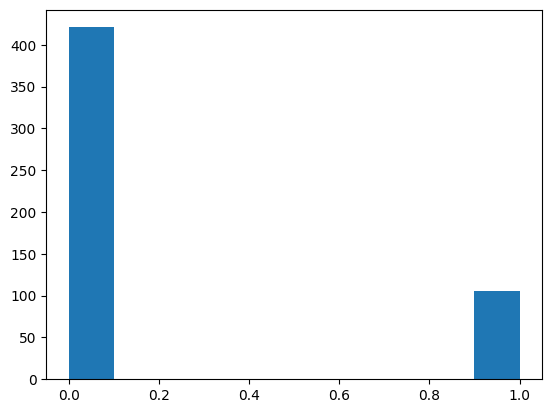

In [45]:
import matplotlib.pyplot as plt
plt.hist(y_up)

In [72]:
model2 = nn.Sequential(nn.Linear(2156, 2156*2), nn.ReLU(), nn.Linear(2156*2, 2156//2), nn.ReLU(), nn.Linear(2156//2, 2), nn.Softmax(dim=1)).to(device)



torch.Size([2156])